# 🎬 Day 29 - Movie Box Office Revenue Prediction
### Predicting box office revenue using movie metadata with regression models

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# modeling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)

In [2]:
df = pd.read_csv("tmdb_5000_movies.csv")   # update path if needed
display(df.shape)
display(df.head(2))

(4803, 20)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [3]:
print("Columns:", df.columns.tolist())
print("Total rows:", len(df))
df['revenue'].describe()
# Many zeros in revenue in TMDB datasets — check count
(df['revenue'] == 0).mean()

Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']
Total rows: 4803


np.float64(0.29710597543202166)

In [4]:
f = df[df['revenue'] > 0].copy()
print("Kept rows with revenue > 0:", len(df))

Kept rows with revenue > 0: 4803


In [5]:
# Convert release_date to datetime and extract features
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day']   = df['release_date'].dt.day
df['release_weekday'] = df['release_date'].dt.weekday
# runtime: numeric
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
# budget, revenue numeric
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [6]:
# revenue is skewed — use log transform for training
df['revenue_log1p'] = np.log1p(df['revenue'])

In [7]:
# TMDB columns often are JSON-like strings. We'll parse `genres` and `crew`.
def parse_json_list_field(s):
    if pd.isna(s):
        return []
    try:
        parsed = json.loads(s.replace("'", '"')) if isinstance(s, str) else s
        if isinstance(parsed, list):
            return parsed
        return []
    except Exception:
        # fallback: try eval (cautious)
        try:
            parsed = eval(s)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []

# genres -> list of genre names
df['genres_parsed'] = df['genres'].apply(parse_json_list_field).apply(lambda L: [d.get('name') for d in L if isinstance(d, dict) and 'name' in d])

# production_companies -> list of names
df['prod_companies'] = df['production_companies'].apply(parse_json_list_field).apply(lambda L: [d.get('name') for d in L if isinstance(d, dict) and 'name' in d])

# Also parse cast & crew if present (common TMDB variants use separate files; if not present this returns empty)
if 'cast' in df.columns:
    df['cast_parsed'] = df['cast'].apply(parse_json_list_field).apply(lambda L: [d.get('name') for d in L if isinstance(d, dict) and 'name' in d])
else:
    df['cast_parsed'] = [[] for _ in range(len(df))]

if 'crew' in df.columns:
    # extract director(s)
    def get_director(crew_list):
        for member in crew_list:
            if isinstance(member, dict) and member.get('job') == 'Director':
                return member.get('name')
        return None
    df['crew_parsed'] = df['crew'].apply(parse_json_list_field)
    df['director'] = df['crew_parsed'].apply(get_director)
else:
    df['crew_parsed'] = [[] for _ in range(len(df))]
    df['director'] = None

In [8]:
# number of genres, number of production companies, number of cast members available
df['n_genres'] = df['genres_parsed'].apply(len)
df['n_prod_companies'] = df['prod_companies'].apply(len)
df['n_cast'] = df['cast_parsed'].apply(len)

# top cast (first 3 names) as a single string (optional)
df['top_3_cast'] = df['cast_parsed'].apply(lambda L: ','.join(L[:3]) if isinstance(L, list) else '')

# simplify language & original_language
df['original_language'] = df['original_language'].fillna('unknown')

# drop columns we won't use directly
# NOTE: adjust list depending on dataset columns you want to keep
drop_cols = ['homepage', 'tagline', 'status', 'overview', 'keywords', 'spoken_languages', 'production_countries']
for c in drop_cols:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

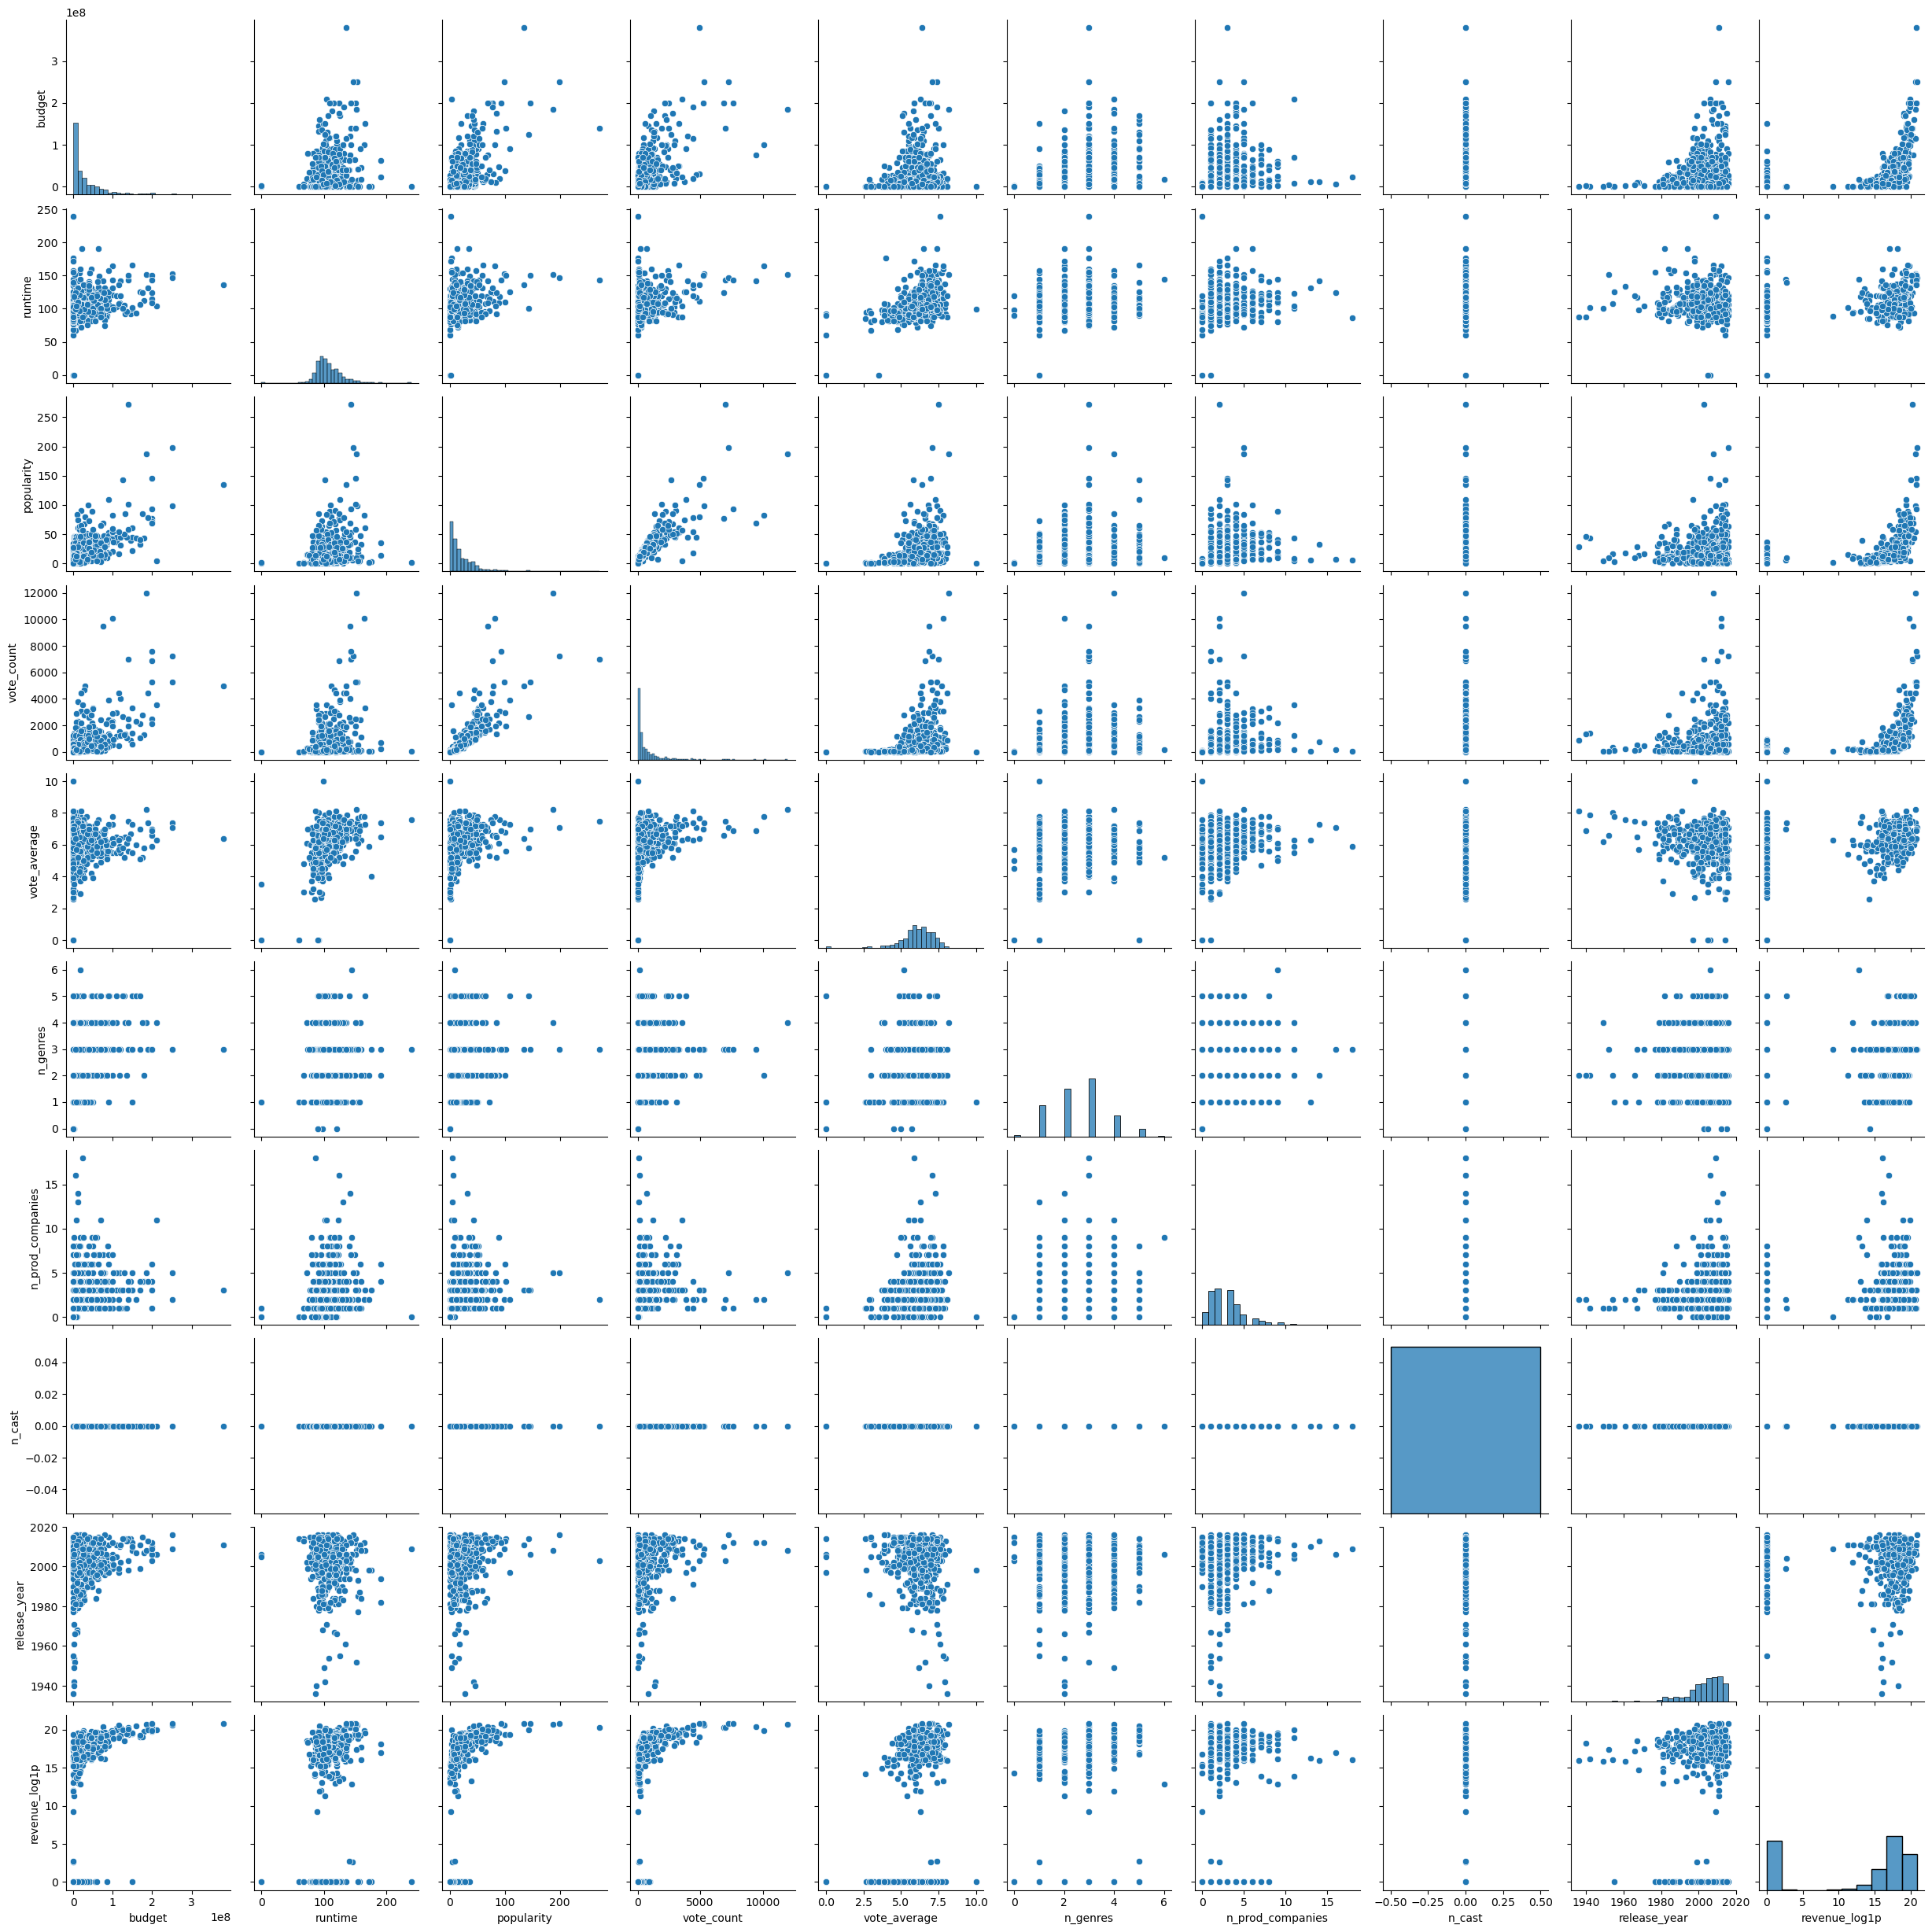

In [9]:
numeric_feats = ['budget','runtime','popularity','vote_count','vote_average','n_genres','n_prod_companies','n_cast','release_year']
present_numeric = [c for c in numeric_feats if c in df.columns]
sns.pairplot(df[present_numeric + ['revenue_log1p']].dropna().sample(min(500, len(df))))
plt.show()

In [10]:
# We'll encode presence of top directors and top genres as binary features (multi-hot).
TOP_DIRECTORS = df['director'].value_counts().head(40).index.tolist()
TOP_GENRES = pd.Series([g for L in df['genres_parsed'] for g in L]).value_counts().head(20).index.tolist()
TOP_CAST = pd.Series([c for L in df['cast_parsed'] for c in L]).value_counts().head(200).index.tolist()
TOP_PROD = pd.Series([p for L in df['prod_companies'] for p in L]).value_counts().head(50).index.tolist()

def make_multi_hot(series_of_lists, top_list, prefix):
    """Return dataframe of multi-hot features for top_list presence."""
    out = pd.DataFrame(0, index=series_of_lists.index, columns=[f"{prefix}__{t}" for t in top_list])
    for idx, L in series_of_lists.items():
        if not L:
            continue
        for item in L:
            if item in top_list:
                out.at[idx, f"{prefix}__{item}"] = 1
    return out

# genres multi-hot
genres_mh = make_multi_hot(df['genres_parsed'], TOP_GENRES, 'genre')
prod_mh   = make_multi_hot(df['prod_companies'], TOP_PROD, 'prodco')
cast_mh   = make_multi_hot(df['cast_parsed'], TOP_CAST, 'cast')

# director categorical top-N (if director not in top, label 'other')
df['director_top'] = df['director'].where(df['director'].isin(TOP_DIRECTORS), 'OTHER')

In [11]:
# Numeric columns to use
num_cols = [c for c in ['budget','runtime','popularity','vote_count','vote_average','n_genres','n_prod_companies','n_cast','release_month','release_year'] if c in df.columns]

# Categorical columns to use
cat_cols = ['original_language','director_top','release_weekday']  # release_weekday as categorical

X_base = df[num_cols + cat_cols].copy()
# attach multi-hot features (genres, prod, cast)
X = pd.concat([X_base, genres_mh, prod_mh, cast_mh], axis=1).fillna(0)
y = df['revenue_log1p'].values  # target transformed
X.shape, y.shape

((4803, 83), (4803,))

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(3842, 83) (961, 83)


In [13]:
# numeric transformer
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical transformer (for director_top & language & weekday)
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Identify which columns are numeric vs categorical in X
numeric_features = [c for c in X_train.columns if any(c.startswith(prefix) for prefix in ['budget','runtime','popularity','vote_count','vote_average','n_genres','n_prod_companies','n_cast','release_month','release_year'])]
# We'll treat director_top, original_language, release_weekday as categorical
categorical_features = [c for c in ['director_top','original_language','release_weekday'] if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough'  # leave multi-hot features as-is
)

In [14]:
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('model', rf)
])

print("Training RandomForest...")
pipe_rf.fit(X_train, y_train)

Training RandomForest...


Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['budget', 'runtime',
                                                   'popularity', 'vote_count',
                                                   'vote_average', 'n_genres',
                                                   'n_prod_companies', 'n_cast',
                                                   'release_month',
                                                   'release_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['director_top',
                                                   'original_language',
                                                   'release_weekday'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [15]:
def evaluate_model(pipe, X_tr, y_tr, X_te, y_te, name="model"):
    # predictions (log scale)
    ypred_tr = pipe.predict(X_tr)
    ypred_te = pipe.predict(X_te)
    # back-transform to original revenue
    y_tr_orig = np.expm1(y_tr)
    y_te_orig = np.expm1(y_te)
    ypred_tr_orig = np.expm1(ypred_tr)
    ypred_te_orig = np.expm1(ypred_te)

    def metrics(y_true, y_pred, label):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        print(f"{label} — RMSE: {rmse:,.2f}, MAE: {mae:,.2f}, R2: {r2:.4f}")

    print(f"Results for {name}: (metrics on original revenue scale)")
    metrics(y_tr_orig, ypred_tr_orig, 'Train')
    metrics(y_te_orig, ypred_te_orig, 'Test')

evaluate_model(pipe_rf, X_train, y_train, X_test, y_test, "RandomForest")

Results for RandomForest: (metrics on original revenue scale)
Train — RMSE: 44,994,218.92, MAE: 20,123,721.05, R2: 0.9240
Test — RMSE: 66,765,897.48, MAE: 35,682,831.62, R2: 0.8289


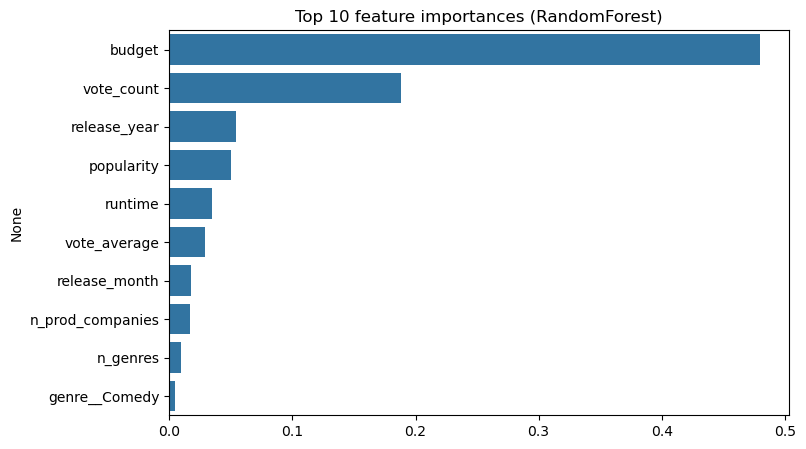

In [16]:
# We need the feature names after the preprocessor. Build them:
def get_feature_names_from_preprocessor(preprocessor, X_sample):
    # numeric features: after scaler/num -> numeric_features order
    out_names = []
    # numeric
    num_feats = numeric_features
    out_names.extend(num_feats)
    # categorical onehot names
    if categorical_features:
        cat_pipe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_names = cat_pipe.get_feature_names_out(categorical_features).tolist()
        out_names.extend(cat_names)
    # remainder passed through: all columns not in numeric_features or categorical_features
    remainder_cols = [c for c in X_sample.columns if c not in numeric_features + categorical_features]
    out_names.extend(remainder_cols)
    return out_names

feature_names = get_feature_names_from_preprocessor(preprocessor, X_train)
# get importances
importances = pipe_rf.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(y=feat_imp.index, x=feat_imp.values)
plt.title("Top 10 feature importances (RandomForest)")
plt.show()

In [17]:
param_dist = {
    'model__n_estimators': [100, 200, 400],
    'model__max_depth': [8, 12, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}
rs = RandomizedSearchCV(pipe_rf, param_distributions=param_dist, n_iter=12,
                        scoring='neg_root_mean_squared_error', cv=3, n_jobs=-1, random_state=RANDOM_STATE, verbose=2)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)
best_rf = rs.best_estimator_
evaluate_model(best_rf, X_train, y_train, X_test, y_test, "RandomForest (tuned)")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 8}
Results for RandomForest (tuned): (metrics on original revenue scale)
Train — RMSE: 85,297,923.83, MAE: 38,511,839.90, R2: 0.7268
Test — RMSE: 73,962,294.15, MAE: 38,885,831.69, R2: 0.7900


In [18]:
best_model = best_rf  
joblib.dump(best_model, "tmdb_revenue_model.pkl")
print("Saved model to tmdb_revenue_model.pkl")

Saved model to tmdb_revenue_model.pkl
